### **Multi-class classfication**

##### **1. Creating a toy multi-class dataset**

In [65]:
import torch
import matplotlib.pyplot as plt

from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set hyperparameters
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# train_hyperparameters
lr = 0.03
epochs = 1000

device = "cuda:0" if torch.cuda.is_available() else "cpu"


# Generate blobs
X_blob, y_blob = make_blobs(
    n_samples=1000,
    n_features=NUM_FEATURES,
    centers=NUM_CLASSES,
    cluster_std=1.5,
    random_state=RANDOM_SEED
)

# turn data into tensors

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

#Split the dataset

X_blob_train,X_blob_test,y_blob_train,y_blob_test = train_test_split(X_blob,
                                                                     y_blob,
                                                                     test_size=0.2,
                                                                     random_state=RANDOM_SEED)

X_blob_train,X_blob_test = X_blob_train.to(device),X_blob_test.to(device)
y_blob_train,y_blob_test = y_blob_train.to(device),y_blob_test.to(device)


def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred)) * 100
    return acc/100

Text(0.5, 0, 'Features_1')

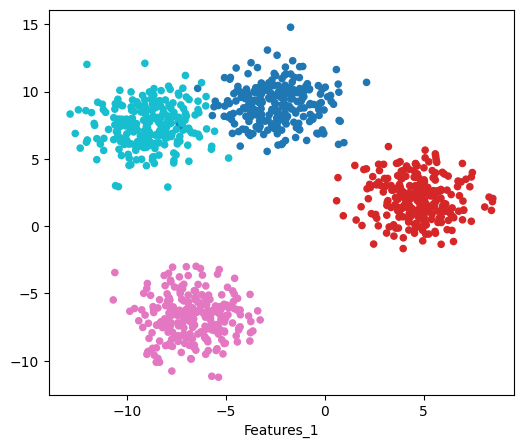

In [57]:
# Visualize
plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=y_blob, cmap='tab10', s=20)
plt.xlabel("Features_1")

In [95]:
# BUILD THE MODEL
class multi_classfication(nn.Module):

    def __init__(self):
        super().__init__()

        self.layers=nn.Sequential(
            nn.Linear(in_features=2,out_features=16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.ReLU(),
            nn.Linear(8,NUM_CLASSES)
        )

    def forward(self,x):
        return self.layers(x)

model = multi_classfication()
model.to(device)

# decide loss functions and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=lr)

# traing_test_loop

def training_test_loop(epochs = 100):

    for epoch in range(epochs):
        
        model.train()
        
        # forward pass
        y_train_logits = model(X_blob_train)
        y_train_preds = torch.argmax(y_train_logits,dim=1)
        
        #calculate the loss
        train_loss=loss_fn(y_train_logits,y_blob_train)
        train_acc=accuracy_fn(y_blob_train,y_train_preds)
        
        # optimizer zero grad
        optimizer.zero_grad()
        
        # loss backward
        train_loss.backward()
        # optimizer step
        optimizer.step()


        # testing
        model.eval()
        with torch.inference_mode():
            
            y_test_logits=model(X_blob_test)
            y_test_preds=torch.argmax(y_test_logits,dim=1)
            test_loss=loss_fn(y_test_logits,y_blob_test)
            test_acc = accuracy_fn(y_blob_test, y_test_preds)

        if epoch % 100 == 0:
            print(f"Epoch: {epoch:3d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


In [97]:
training_test_loop(200)

Epoch:   0 | Train Loss: 0.5425 | Train Acc: 99.88% | Test Loss: 0.5822 | Test Acc: 100.00%
Epoch: 100 | Train Loss: 0.1408 | Train Acc: 100.00% | Test Loss: 0.1468 | Test Acc: 100.00%


### Classfication metrics
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report

tensor(2)

Epoch:   0 | Train Loss: 1.4119 | Train Acc: 9.75% | Test Loss: 1.4194 | Test Acc: 11.50%
Epoch: 100 | Train Loss: 1.3085 | Train Acc: 25.12% | Test Loss: 1.3142 | Test Acc: 25.00%
Epoch: 200 | Train Loss: 1.2043 | Train Acc: 70.25% | Test Loss: 1.2059 | Test Acc: 66.00%
Epoch: 300 | Train Loss: 1.0338 | Train Acc: 75.25% | Test Loss: 1.0286 | Test Acc: 71.00%
Epoch: 400 | Train Loss: 0.8487 | Train Acc: 75.62% | Test Loss: 0.8388 | Test Acc: 71.00%
